In [3]:
import os
import numpy as np  
import matplotlib.pyplot as plt

In [4]:
%pwd

'/Users/eren/Desktop/GNN-Traffic-Forecasting/GNN-Traffic-Forecast/research'

In [5]:
os.chdir('../')

In [6]:
data = np.load('artifacts/data_preprocessing/PEMS04_r1_d0_w0_astcgn.npz') 

We have 307 detectors each detector detect three features such as speed of cars, congestion,etc. And we store that data every five minutes. In 5 mins, our data will be (1, 307, 3) In 1 hour , our data will be (12, 307, 3) In 1 day ,our data will be (12 24, 307, 3) In 59 days, our data will be (12 24 * 59, 307, 3) = (16992, 307, 3). The 12 in the end is "points per hour".

In [7]:
#print(data)
print(data['train_x'].shape)
print(data['train_target'].shape)
print(data["train_timestamp"].shape)

(10181, 307, 3, 12)
(10181, 307, 12)
(10181, 1)


In [9]:

print( data["train_x"])

[[[[-0.92810273 -0.93449342 -0.87058653 ... -0.27625247 -0.41045693
    -0.41684762]
   [-0.91151028 -0.91777933 -0.87807536 ... -0.62313411 -0.67328649
    -0.67537617]
   [ 0.54617551  0.47213358  0.60787711 ...  0.27468846  0.2993691
     0.39809166]]

  [[-0.96644686 -1.06869788 -1.14538615 ... -0.35933142 -0.64052173
    -0.44241038]
   [-0.8383714  -0.90524123 -0.93031742 ... -0.36192382 -0.51029127
    -0.31804049]
   [ 0.60787711  0.63255775  0.48447391 ...  0.06490301 -0.02147924
    -0.37934853]]

  [[-0.74916344 -0.72360068 -0.81946102 ... -0.3145966  -0.43601969
    -0.72999137]
   [-0.77359124 -0.74642537 -0.81747457 ... -0.51029127 -0.58343015
    -0.73597696]
   [ 0.58319647  0.53383519  0.64489807 ...  0.44745294  0.39809166
     0.41043198]]

  ...

  [[-0.96644686 -0.9984003  -0.89614928 ... -0.16122007  0.11357955
    -0.22512696]
   [-0.86762695 -0.87598568 -0.82792299 ... -0.39744842 -0.26370875
    -0.45386984]
   [ 0.48447391  0.31170942  0.39809166 ...  0.225327

In [6]:
# Extract the components
x_train = data['train_x']
train_target = data['train_target']
val_x = data['val_x']
val_target = data['val_target']

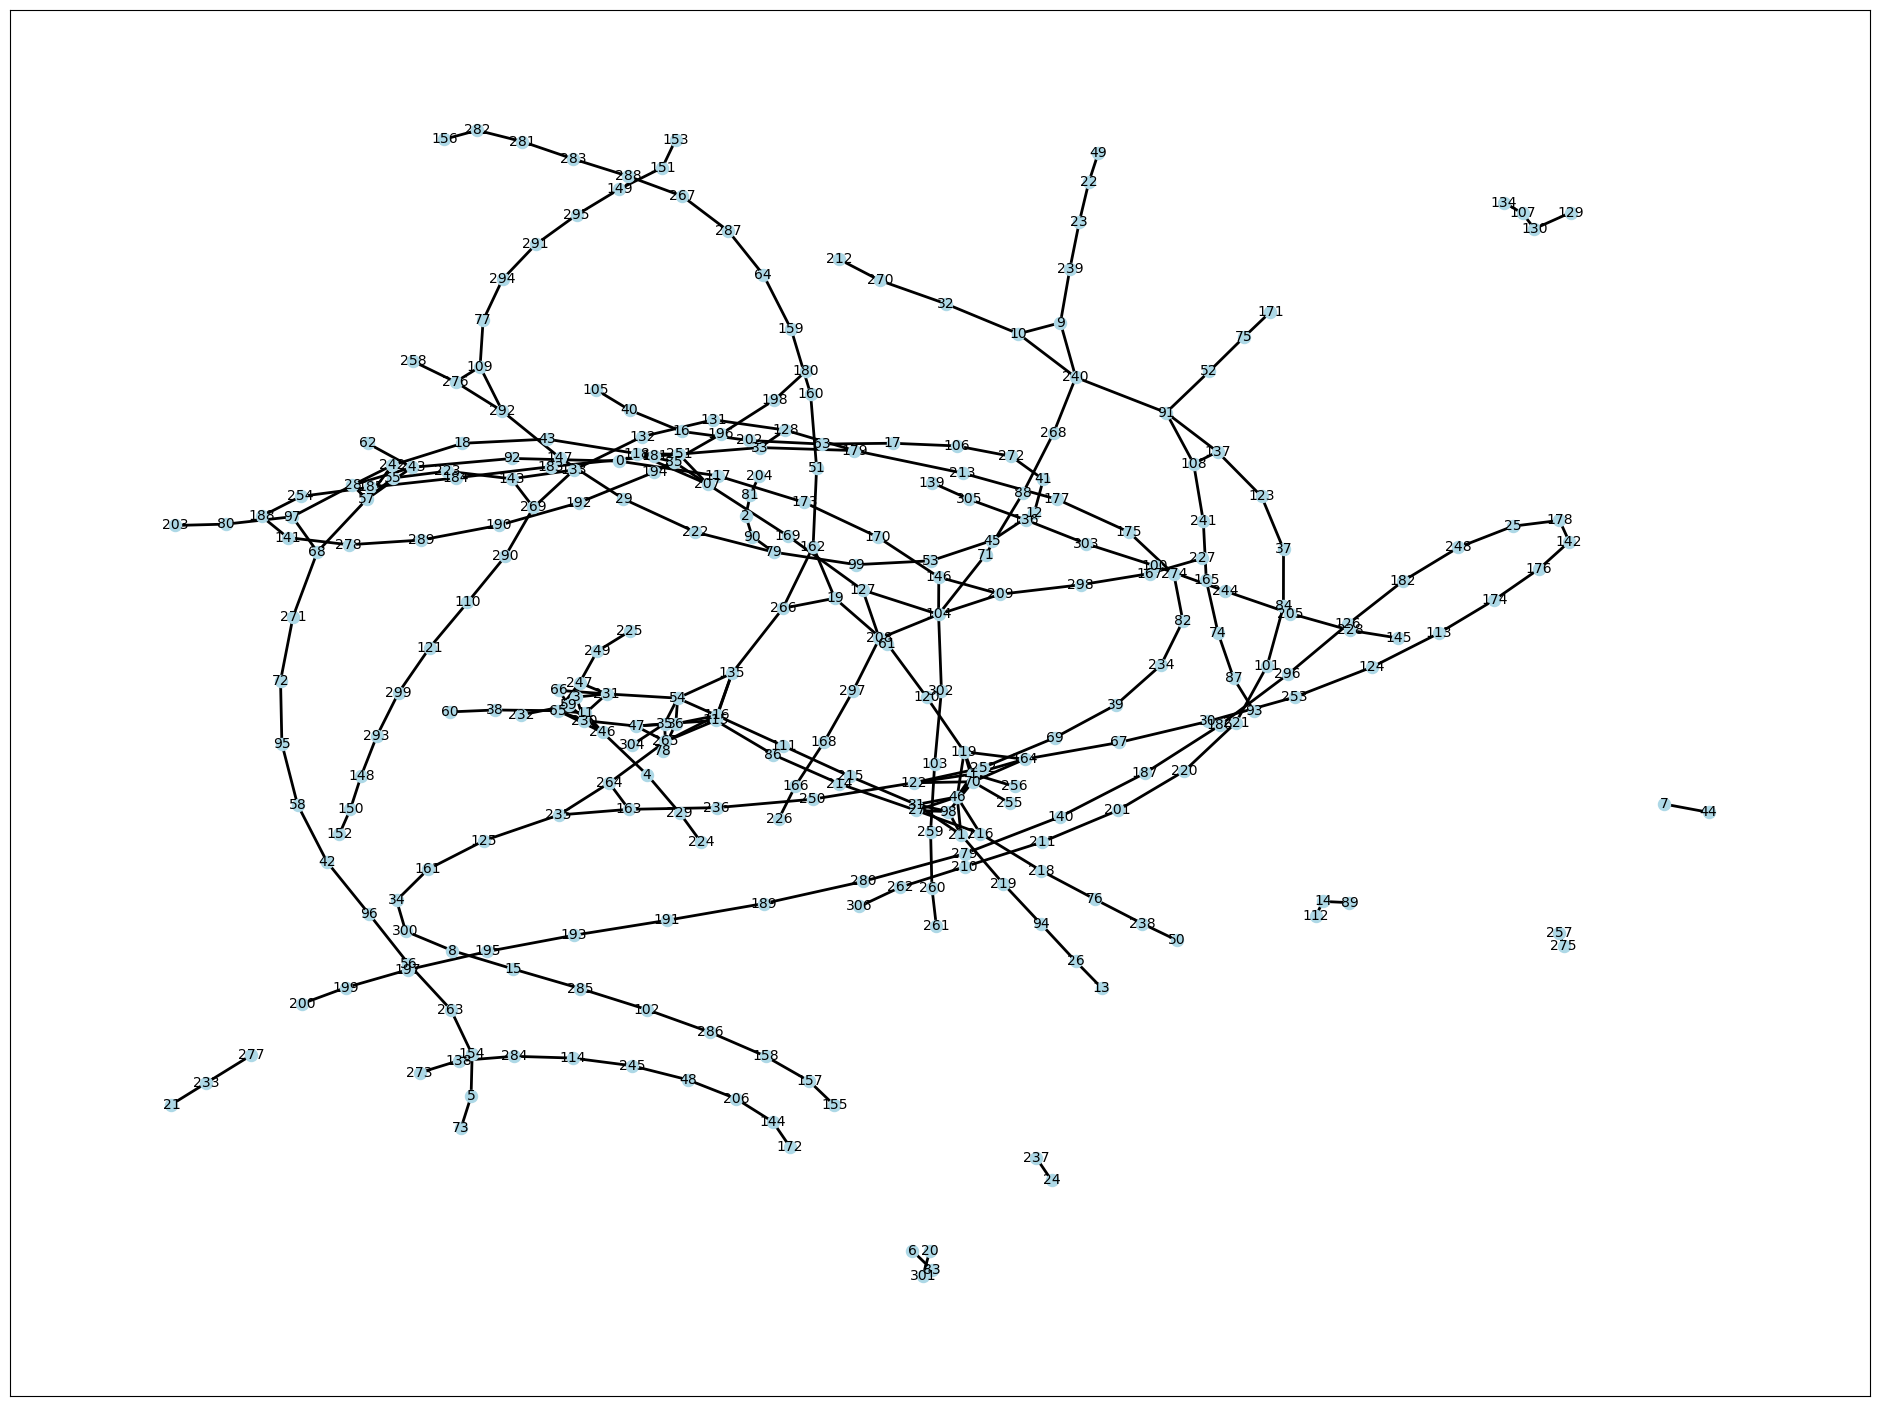

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Read the CSV file into a DataFrame
adj = pd.read_csv('/Users/eren/Desktop/GNN-Traffic-Forecasting/GNN-Traffic-Forecast/artifacts/data_ingestion/PEMS04.csv')

# Assuming the first two columns are node connections
edges = adj.iloc[:, :2].values

# Create a graph from the edge list
G = nx.from_edgelist(edges)
#pos = nx.kamada_kawai_layout(G)

# Draw the graph
plt.figure(figsize=(24, 18))  # Optionally, specify the figure size
nx.draw_networkx(
    G,
    #pos = pos,
    with_labels=True,
    node_color='lightblue',
    node_size=75,  # Adjust node size (default is 300)
    font_size=10,  # Adjust font size for labels
    edge_color='black',  # Adjust edge color
    width=2  # Adjust edge width for better visibility
)
# Show plot
plt.show()

Possible things to predict: 

-Future Traffic Jam.a

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

# Replace with your actual path and file name
edges_file_path = '/path/to/edges.csv'

# Load edges, assuming CSV format with columns 'source', 'target', and 'weight'
edges_df = pd.read_csv(edges_file_path)

# Create a directed graph
G = nx.DiGraph()

# Add edges from the dataframe
for i, row in edges_df.iterrows():
    G.add_edge(row['source'], row['target'], weight=row['weight'])

# Print out the edges and their weights
for edge in G.edges(data=True):
    print(edge)

# Visualize the graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=500, node_color='lightblue', font_size=10)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/path/to/edges.csv'